### Plot Power/Load and Setpoints results

In [7]:
import math
import os
from pathlib import Path
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt


convert_epoch_datetime_files = {"scheduleData.csv":"scheduleData_dataset.csv", 
                                "baseline_powerData.csv":"baseline_dataset.csv","flexible_powerData.csv":"flexible_dataset.csv", 
                                "baseline_tempData.csv":"baseline_tempData_dataset.csv", "flexible_tempData.csv":"flexible_tempData_dataset.csv"
                                } #input:output

import csv
from datetime import datetime
import pytz

def convert_epoch_to_datetime(epoch_time):
  return datetime.fromtimestamp(epoch_time, pytz.utc).strftime('%Y-%m-%d %H:%M:%S')

for input_filename, output_filename in convert_epoch_datetime_files.items():
    input_file = input_filename
    output_file = output_filename

    # Read CSV and convert epoch time
    with open(input_file, 'r') as csv_in, open(output_file, 'w', newline='') as csv_out:
        reader = csv.DictReader(csv_in)
        fieldnames = reader.fieldnames

        # Replace the original EpochTimeColumn with ConvertedDateTime in fieldnames
        fieldnames[fieldnames.index('time')] = 'time'

        writer = csv.DictWriter(csv_out, fieldnames=fieldnames)
        writer.writeheader()

        for row in reader:
            epoch_time = float(row['time'])  # Assuming 'EpochTimeColumn' has been replaced
            converted_datetime = convert_epoch_to_datetime(epoch_time)

            row['time'] = converted_datetime
            writer.writerow(row)

    print(f"Conversion complete. Results saved in '{output_file}'.")

Conversion complete. Results saved in 'scheduleData_dataset.csv'.
Conversion complete. Results saved in 'baseline_dataset.csv'.
Conversion complete. Results saved in 'flexible_dataset.csv'.
Conversion complete. Results saved in 'baseline_tempData_dataset.csv'.
Conversion complete. Results saved in 'flexible_tempData_dataset.csv'.


In [8]:
# Choose a specific day 
selected_day = '1970-02-06' 

# The control valve of the radiator tracks the measured indoor temperature. The baseline controller implements a night setback of 3 K outside of operating hours. 
# After night setback, the setpoint is reset to 22 °C 2 hours before the next operating hour (4 hours on Mondays), to make sure the building has reached the setpoint temperature before the building is occupied again.


name_test_case = 'B3'#: Virtual single commercial hydronic'

scenario_test_case = 'B3_FixSc1'

price_signal_identifier = 'PriceElectricPowerHighlyDynamic'

stp_identifier = 'oveTZonSet_u'
temperature_identifier = 'reaTZon_y'

price_threshold = 0.05093

Occ_identifier = 'LowerSetp[1]'
LowerSetp_identifier = 'LowerSetp[1]'
UpperSetp_identifier = 'UpperSetp[1]'
otemp_identifier = 'TDryBul'

In [9]:
def get_price_threshold(price_schedule): 
   
    # Sort the prices in ascending order
    price_schedule.sort()

    # Calculate the index of the third quartile
    n = len(price_schedule)
    k = (3.0 * n - 1) / 4

    # Determine the price threshold as the third quartile
    if k == int(k):
        priceThreshold = price_schedule[int(k) - 1]
    else:
        priceThreshold = (price_schedule[int(k) - 1] + price_schedule[int(k)]) / 2

    return priceThreshold


In [10]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator
# import numpy as np
# from matplotlib.patches import Patch

# schedule_df = pd.read_csv('scheduleData_dataset.csv', parse_dates=['time'], index_col='time')
# baseline_df = pd.read_csv('baseline_dataset.csv', parse_dates=['time'], index_col='time')
# flexible_df = pd.read_csv('flexible_dataset.csv', parse_dates=['time'], index_col='time')
# baseline_temp_df = pd.read_csv('baseline_tempData_dataset.csv', parse_dates=['time'], index_col='time')
# flexible_temp_df = pd.read_csv('flexible_tempData_dataset.csv', parse_dates=['time'], index_col='time')

# #display(baseline_df.head())
# #display(flexible_df.head())

# baseline_df_selected_day = baseline_df.loc[selected_day]
# flexible_df_selected_day = flexible_df.loc[selected_day]
# schedule_df_selected_day = schedule_df.loc[selected_day]
# baseline_temp_df_selected_day = baseline_temp_df.loc[selected_day]
# flexible_temp_df_selected_day = flexible_temp_df.loc[selected_day]


# baseline_df_selected_day['Total'] = baseline_df_selected_day.sum(axis=1)
# flexible_df_selected_day['Total'] = flexible_df_selected_day.sum(axis=1)

# # Resample the selected day data for every 15 minutes and calculate the sum
# baseline_df_resampled = baseline_df_selected_day['Total'].resample('15T').mean()/1000
# flexible_df_resampled = flexible_df_selected_day['Total'].resample('15T').mean()/1000
# occ_df_resampled = schedule_df_selected_day[Occ_identifier].resample('1H').mean()

# lowSp_df_resampled = schedule_df_selected_day[LowerSetp_identifier].resample('15T').mean() - 273.15
# uppSp_df_resampled = schedule_df_selected_day[UpperSetp_identifier].resample('15T').mean() - 273.15


# flexible_setpoint_df_resampled = flexible_temp_df_selected_day[stp_identifier].resample('1T').mean() - 273.15
# baseline_setpoint_df_resampled = baseline_temp_df_selected_day[stp_identifier].resample('1T').mean() - 273.15

# flexible_temp_df_resampled = flexible_temp_df_selected_day[temperature_identifier].resample('1T').mean() - 273.15
# baseline_temp_df_resampled = baseline_temp_df_selected_day[temperature_identifier].resample('1T').mean() - 273.15


# price_df_resampled = schedule_df_selected_day[price_signal_identifier].resample('15T').mean()


# shed_price_df = price_df_resampled[price_df_resampled >= price_threshold] 

# #display(baseline_df_resampled.head(81))
# #display(shed_price_df.head(81))
# #display(lowSp_df_resampled.head(24))

# hours = baseline_df_resampled.index.hour

# # Plot the results for both CSV files
# plt.figure(figsize=(10, 6))

# # Plot electric power 
# baseline_load_line, = plt.plot(np.linspace(0, 24, len(baseline_df_resampled)), baseline_df_resampled, linestyle='-', linewidth=1.8, 
#                                label='Baseline Load (kW)', color = '#3c054f', marker='o')
# flex_load_line, = plt.plot(np.linspace(0, 24, len(flexible_df_resampled)), flexible_df_resampled, linestyle='-', linewidth=1.8, 
#                            label='Flexible Load (kW)', color = '#ff6361', marker='o')
# plt.ylabel('Total Load (kW)')
# plt.xlabel('Time (hours)')

# # Plot occupancy on secondary y-axis
# ax_temp = plt.twinx()
# setpoint_line, = ax_temp.plot(np.linspace(0, 24, len(flexible_setpoint_df_resampled)), flexible_setpoint_df_resampled, color = 'red',
#                               linestyle='-', linewidth=1.8, label='Flexible Setpoint')

# baseline_setpoint_line, = ax_temp.plot(np.linspace(0, 24, len(baseline_setpoint_df_resampled)), baseline_setpoint_df_resampled, color = 'black',
#                               linestyle='-', linewidth=1.8, label='Baseline Setpoint')


# baseline_temp_line, = ax_temp.plot(np.linspace(0, 24, len(baseline_temp_df_resampled)), baseline_temp_df_resampled, color = 'royalblue',
#                               linestyle='-', linewidth=1.8, label='Flexible Temperature')


# temp_line, = ax_temp.plot(np.linspace(0, 24, len(flexible_temp_df_resampled)), flexible_temp_df_resampled, color = 'orange',
#                               linestyle='-', linewidth=1.8, label='Flexible Temperature')
# #comf_line, = ax_occ.plot(np.linspace(0, 24, len(lowSp_df_resampled)), lowSp_df_resampled, color = 'gray',
# #                              linestyle='-', linewidth=1.8, label='', marker='o')

# #comf_line, = ax_occ.plot(np.linspace(0, 24, len(uppSp_df_resampled)), uppSp_df_resampled, color = 'gray',
# #                              linestyle='-', linewidth=1.8, label='', marker='o')
# ax_temp.set_ylabel('Temperature')

# # Combine the legends
# #plt.legend(handles=[baseline_load_line, flex_load_line, cool_line, heat_line, temp_line], loc='upper right')
# custom_ticks = np.arange(0, 24, 2)  # Generate ticks from 0 to 24 with step 2
# plt.xticks(custom_ticks)

# plt.gca().xaxis.set_major_locator(MultipleLocator(2))

# plt.title(f'{name_test_case} for {selected_day[5:]}', fontsize=14)

# # Adding vertical gridlines
# for i in range(0, 24, 2):
#     plt.axvline(i, color='gray', linewidth=0.3)

# plt.xlim(0, 24)
# plt.grid(which='both', axis='both', linewidth=0.3)  # Show both major and minor gridlines


# # Adding a shaded area for occ
# occ_hour_list = []
# non_occ_hour_list = []

# for i in range(len(lowSp_df_resampled)):
#     if lowSp_df_resampled[i] > 16:
#         start_hour = lowSp_df_resampled.index[i].hour
#         start_minute = lowSp_df_resampled.index[i].minute/60
#         plt.axvspan(start_hour + start_minute, start_hour + start_minute + 0.25, alpha=0.2, hatch='////', color='gray')
#         occ_hour_list.append(start_hour + start_minute)

#     else:
#         non_occ_hour_list.append(lowSp_df_resampled.index[i].hour)

# occ_legend_patch = Patch(facecolor='gray', alpha=0.2, hatch='////', edgecolor='gray')


# # Adding a shaded area for shed

# for i in range(len(price_df_resampled)-1):
#     if price_df_resampled[i] >= price_threshold:
        
#         start_hour = price_df_resampled.index[i].hour
#         start_minute = price_df_resampled.index[i].minute/60
        
#         if start_hour + start_minute in occ_hour_list:
#             plt.axvspan(start_hour + start_minute, start_hour + start_minute + 0.25, alpha=0.2, color='yellow')


# shed_legend_patch = Patch(facecolor='yellow', alpha=0.2, edgecolor='gray')

# # Adding a shaded area for shift
# freq_shift = {}

# def check_future_condition(price, occ, price_threshold):
#     for i in range(len(price)):
#         # Check if both price and occ are greater than their thresholds
#         if price[i] > price_threshold and occ[i] > 15:
#             # Check if all the previous elements of occ are less than or equal to min and that price is greater than threshold 
#             for j in range(i):
#                 if occ[j] <= 15 and price[j] > price_threshold:
#                     return False
#             # If no previous element violates the condition, return True
#             return True
#     # If no element satisfies the condition, return False
#     return False


# for i in range(len(price_df_resampled) - 3):

#     current_condition = price_df_resampled[i] < price_threshold
#     future_hours_conditions = check_future_condition(price_df_resampled[i+1:i+4*3+1], lowSp_df_resampled[i+1:i+4*3+1], price_threshold)

#     if (current_condition and future_hours_conditions):
        
#         start_hour = lowSp_df_resampled.index[i].hour
#         start_minute = lowSp_df_resampled.index[i].minute/60
#         plt.axvspan(start_hour + start_minute, start_hour + start_minute + 0.25, alpha=0.2, color='lightgreen')

# shift_legend_patch = Patch(facecolor='lightgreen', alpha=0.2, edgecolor='gray')


# handles = [baseline_load_line, flex_load_line, baseline_setpoint_line, setpoint_line, baseline_temp_line, temp_line, occ_legend_patch, shed_legend_patch, shift_legend_patch]

# labels = ['Baseline Load', 'Flexible Load', 'Baseline Temperature Setpoint', 'Flexible Temperature Setpoint', 'Baseline Temperature','Flexible Temperature', 'Occupancy', 'Shed Event', 'Shift Event']
# plt.legend(handles=handles, labels=labels, loc='upper right')


# plt.tight_layout()
# plt.subplots_adjust(top=0.95)

# plt.savefig(f'{scenario_test_case}_demand_temperature.png')

# plt.show()



In [11]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator
# import numpy as np
# from matplotlib.patches import Patch

# schedule_df = pd.read_csv('scheduleData_dataset.csv', parse_dates=['time'], index_col='time')
# baseline_df = pd.read_csv('baseline_dataset.csv', parse_dates=['time'], index_col='time')
# flexible_df = pd.read_csv('flexible_dataset.csv', parse_dates=['time'], index_col='time')
# baseline_temp_df = pd.read_csv('baseline_tempData_dataset.csv', parse_dates=['time'], index_col='time')
# flexible_temp_df = pd.read_csv('flexible_tempData_dataset.csv', parse_dates=['time'], index_col='time')

# #display(baseline_df.head())
# #display(flexible_df.head())

# baseline_df_selected_day = baseline_df.loc[selected_day]
# flexible_df_selected_day = flexible_df.loc[selected_day]
# schedule_df_selected_day = schedule_df.loc[selected_day]
# baseline_temp_df_selected_day = baseline_temp_df.loc[selected_day]
# flexible_temp_df_selected_day = flexible_temp_df.loc[selected_day]


# baseline_df_selected_day['Total'] = baseline_df_selected_day.sum(axis=1)
# flexible_df_selected_day['Total'] = flexible_df_selected_day.sum(axis=1)

# # Resample the selected day data for every 15 minutes and calculate the sum
# baseline_df_resampled = baseline_df_selected_day['Total'].resample('15T').mean()/1000
# flexible_df_resampled = flexible_df_selected_day['Total'].resample('15T').mean()/1000
# occ_df_resampled = schedule_df_selected_day[Occ_identifier].resample('1H').mean()

# lowSp_df_resampled = schedule_df_selected_day[LowerSetp_identifier].resample('15T').mean() - 273.15
# uppSp_df_resampled = schedule_df_selected_day[UpperSetp_identifier].resample('15T').mean() - 273.15


# flexible_setpoint_df_resampled = flexible_temp_df_selected_day[stp_identifier].resample('1T').mean() - 273.15
# baseline_setpoint_df_resampled = baseline_temp_df_selected_day[stp_identifier].resample('1T').mean() - 273.15

# flexible_temp_df_resampled = flexible_temp_df_selected_day[temperature_identifier].resample('1T').mean() - 273.15
# baseline_temp_df_resampled = baseline_temp_df_selected_day[temperature_identifier].resample('1T').mean() - 273.15


# price_df_resampled = schedule_df_selected_day[price_signal_identifier].resample('15T').mean()


# shed_price_df = price_df_resampled[price_df_resampled >= price_threshold] 

# #display(baseline_df_resampled.head(81))
# #display(shed_price_df.head(81))
# #display(lowSp_df_resampled.head(24))

# hours = baseline_df_resampled.index.hour

# # Plot the results for both CSV files
# plt.figure(figsize=(10, 6))

# # Plot electric power 
# baseline_load_line, = plt.plot(np.linspace(0, 24, len(baseline_df_resampled)), baseline_df_resampled, linestyle='-', linewidth=1.8, 
#                                label='Baseline Load (kW)', color = '#3c054f', marker='o')
# flex_load_line, = plt.plot(np.linspace(0, 24, len(flexible_df_resampled)), flexible_df_resampled, linestyle='-', linewidth=1.8, 
#                            label='Flexible Load (kW)', color = '#ff6361', marker='o')
# plt.ylabel('Total Load (kW)')
# plt.xlabel('Time (hours)')

# # Plot occupancy on secondary y-axis
# ax_temp = plt.twinx()
# setpoint_line, = ax_temp.plot(np.linspace(0, 24, len(flexible_setpoint_df_resampled)), flexible_setpoint_df_resampled, color = 'red',
#                               linestyle='-', linewidth=1.8, label='Flexible Setpoint')

# baseline_setpoint_line, = ax_temp.plot(np.linspace(0, 24, len(baseline_setpoint_df_resampled)), baseline_setpoint_df_resampled, color = 'black',
#                               linestyle='-', linewidth=1.8, label='Baseline Setpoint')


# baseline_temp_line, = ax_temp.plot(np.linspace(0, 24, len(baseline_temp_df_resampled)), baseline_temp_df_resampled, color = 'royalblue',
#                               linestyle='-', linewidth=1.8, label='Flexible Temperature')


# temp_line, = ax_temp.plot(np.linspace(0, 24, len(flexible_temp_df_resampled)), flexible_temp_df_resampled, color = 'orange',
#                               linestyle='-', linewidth=1.8, label='Flexible Temperature')
# #comf_line, = ax_occ.plot(np.linspace(0, 24, len(lowSp_df_resampled)), lowSp_df_resampled, color = 'gray',
# #                              linestyle='-', linewidth=1.8, label='', marker='o')

# #comf_line, = ax_occ.plot(np.linspace(0, 24, len(uppSp_df_resampled)), uppSp_df_resampled, color = 'gray',
# #                              linestyle='-', linewidth=1.8, label='', marker='o')
# ax_temp.set_ylabel('Temperature')

# # Combine the legends
# #plt.legend(handles=[baseline_load_line, flex_load_line, cool_line, heat_line, temp_line], loc='upper right')
# custom_ticks = np.arange(0, 24, 2)  # Generate ticks from 0 to 24 with step 2
# plt.xticks(custom_ticks)

# plt.gca().xaxis.set_major_locator(MultipleLocator(2))

# plt.title(f'{name_test_case} for {selected_day[5:]}', fontsize=14)

# # Adding vertical gridlines
# for i in range(0, 24, 2):
#     plt.axvline(i, color='gray', linewidth=0.3)

# plt.xlim(0, 24)
# plt.grid(which='both', axis='both', linewidth=0.3)  # Show both major and minor gridlines



# # Adding a shaded area for shed

# for i in range(len(price_df_resampled)-1):
#     if price_df_resampled[i] >= price_threshold:
        
#         start_hour = price_df_resampled.index[i].hour
#         start_minute = price_df_resampled.index[i].minute/60
        
#         if start_hour + start_minute in occ_hour_list:
#             plt.axvspan(start_hour + start_minute, start_hour + start_minute + 0.25, alpha=0.2, color='yellow')


# shed_legend_patch = Patch(facecolor='yellow', alpha=0.2, edgecolor='gray')

# # Adding a shaded area for shift
# freq_shift = {}

# def check_future_condition(price, occ, price_threshold):
#     for i in range(len(price)):
#         # Check if both price and occ are greater than their thresholds
#         if price[i] > price_threshold and occ[i] > 15:
#             # Check if all the previous elements of occ are less than or equal to min and that price is greater than threshold 
#             for j in range(i):
#                 if occ[j] <= 15 and price[j] > price_threshold:
#                     return False
#             # If no previous element violates the condition, return True
#             return True
#     # If no element satisfies the condition, return False
#     return False


# for i in range(len(price_df_resampled) - 3):

#     current_condition = price_df_resampled[i] < price_threshold
#     future_hours_conditions = check_future_condition(price_df_resampled[i+1:i+4*3+1], lowSp_df_resampled[i+1:i+4*3+1], price_threshold)

#     if (current_condition and future_hours_conditions):
        
#         start_hour = lowSp_df_resampled.index[i].hour
#         start_minute = lowSp_df_resampled.index[i].minute/60
#         plt.axvspan(start_hour + start_minute, start_hour + start_minute + 0.25, alpha=0.2, color='lightgreen')

# shift_legend_patch = Patch(facecolor='lightgreen', alpha=0.2, edgecolor='gray')


# handles = [baseline_load_line, flex_load_line, baseline_setpoint_line, setpoint_line, baseline_temp_line, temp_line, shed_legend_patch, shift_legend_patch]

# labels = ['Baseline Load', 'Flexible Load', 'Baseline Temperature Setpoint', 'Flexible Temperature Setpoint', 'Baseline Temperature','Flexible Temperature', 'Shed Event', 'Shift Event']
# plt.legend(handles=handles, labels=labels, loc='upper right')


# plt.tight_layout()
# plt.subplots_adjust(top=0.95)

# plt.savefig(f'{scenario_test_case}_demand_temperature.png')

# plt.show()



C:\Users\fafla\AppData\Local\Temp\ipykernel_7056\201909981.py:22: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  baseline_resampled_df = baseline_df.resample('15T', on='time').mean()
C:\Users\fafla\AppData\Local\Temp\ipykernel_7056\201909981.py:23: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  flexible_resampled_df = flexible_df.resample('15T', on='time').mean()
C:\Users\fafla\AppData\Local\Temp\ipykernel_7056\201909981.py:24: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  baseline_temp_resampled_df = baseline_temp_df.resample('1T', on='time').mean()
C:\Users\fafla\AppData\Local\Temp\ipykernel_7056\201909981.py:25: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  flexible_temp_resampled_df = flexible_temp_df.resample('1T', on='time').mean()
C:\Users\fafla\AppData\Local\T

[0.03729, 0.03729, 0.03729, 0.03729, 0.0328, 0.0328, 0.0328, 0.0328, 0.02971, 0.02971, 0.02971, 0.02971, 0.031, 0.031, 0.031, 0.031, 0.03608, 0.03608, 0.03608, 0.03608, 0.04002, 0.04002, 0.04002, 0.04002, 0.04644, 0.04644, 0.04644, 0.04644, 0.05519, 0.05519, 0.05519, 0.05519, 0.05491, 0.05491, 0.05491, 0.05491, 0.05733, 0.05733, 0.05733, 0.05733, 0.05566, 0.05566, 0.05566, 0.05566, 0.05093, 0.05093, 0.05093, 0.05093, 0.05002, 0.05002, 0.05002, 0.05002, 0.04959, 0.04959, 0.04959, 0.04959, 0.04998, 0.04998, 0.04998, 0.04998, 0.04998, 0.04998, 0.04998, 0.04998, 0.05031, 0.05031, 0.05031, 0.05031, 0.05408, 0.05408, 0.05408, 0.05408, 0.05761, 0.05761, 0.05761, 0.05761, 0.04998, 0.04998, 0.04998, 0.04998, 0.04596, 0.04596, 0.04596, 0.04596, 0.0416, 0.0416, 0.0416, 0.0416, 0.04396, 0.04396, 0.04396, 0.04396, 0.04151, 0.04151, 0.04151, 0.04151]
Price threshold 0.05093


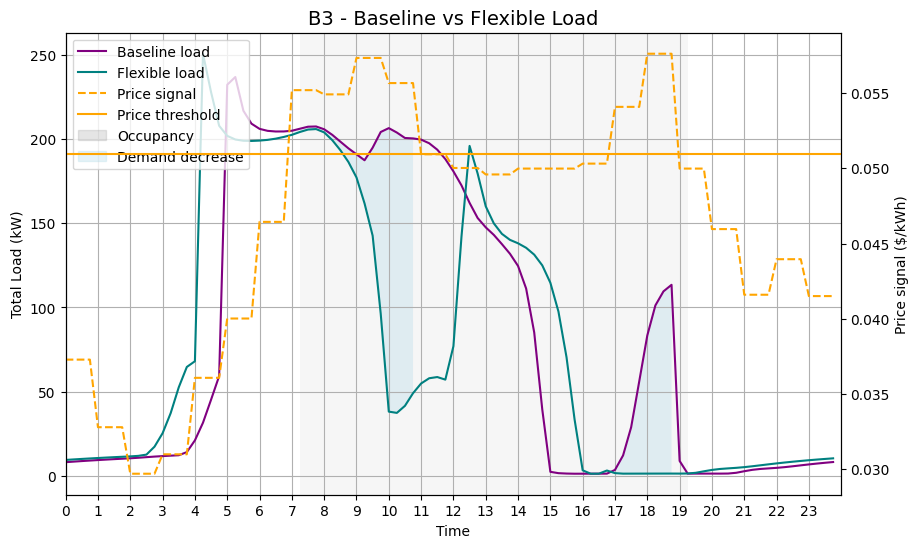

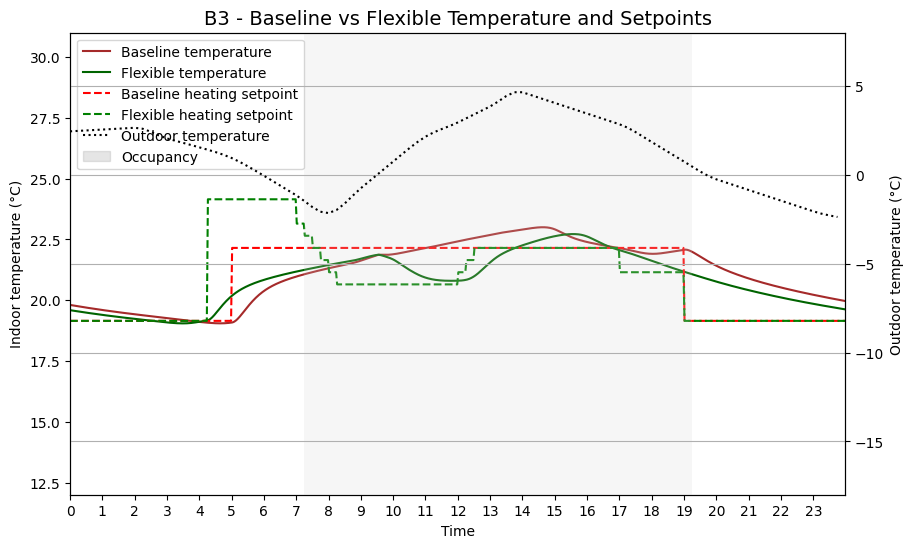

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

# Load datasets
schedule_df = pd.read_csv('scheduleData_dataset.csv')
baseline_df = pd.read_csv('baseline_dataset.csv')
flexible_df = pd.read_csv('flexible_dataset.csv')
baseline_temp_df = pd.read_csv('baseline_tempData_dataset.csv')
flexible_temp_df = pd.read_csv('flexible_tempData_dataset.csv')

# Convert 'time' columns to datetime
schedule_df['time'] = pd.to_datetime(schedule_df['time'])
baseline_df['time'] = pd.to_datetime(baseline_df['time'])
flexible_df['time'] = pd.to_datetime(flexible_df['time'])
baseline_temp_df['time'] = pd.to_datetime(baseline_temp_df['time'])
flexible_temp_df['time'] = pd.to_datetime(flexible_temp_df['time'])

# Resample the data to 15-minute intervals
baseline_resampled_df = baseline_df.resample('15T', on='time').mean()
flexible_resampled_df = flexible_df.resample('15T', on='time').mean()
baseline_temp_resampled_df = baseline_temp_df.resample('1T', on='time').mean()
flexible_temp_resampled_df = flexible_temp_df.resample('1T', on='time').mean()

# Reset the index to make 'time' a column again
baseline_resampled_df.reset_index(inplace=True)
flexible_resampled_df.reset_index(inplace=True)
baseline_temp_resampled_df.reset_index(inplace=True)
flexible_temp_resampled_df.reset_index(inplace=True)

schedule_resampled_df = schedule_df.set_index('time').resample('15T').ffill().reset_index()

# Filter the data for the specific day
baseline_df_selected_day = baseline_resampled_df[baseline_resampled_df['time'].dt.strftime('%Y-%m-%d') == selected_day]
flexible_df_selected_day = flexible_resampled_df[flexible_resampled_df['time'].dt.strftime('%Y-%m-%d') == selected_day]
schedule_df_selected_day = schedule_resampled_df[schedule_resampled_df['time'].dt.strftime('%Y-%m-%d') == selected_day]

baseline_temp_resampled_day_df = baseline_temp_resampled_df[baseline_temp_resampled_df['time'].dt.strftime('%Y-%m-%d') == selected_day] 
flexible_temp_resampled_day_df = flexible_temp_resampled_df[flexible_temp_resampled_df['time'].dt.strftime('%Y-%m-%d') == selected_day] 


# Calculate total load for baseline and flexible scenarios
baseline_df_selected_day['Total'] = baseline_df_selected_day.drop(columns=['time']).sum(axis=1) / 1000  # Convert to kW
flexible_df_selected_day['Total'] = flexible_df_selected_day.drop(columns=['time']).sum(axis=1) / 1000  # Convert to kW

# Plot total load over time for baseline and flexible scenarios with occupancy shaded and pricing on secondary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot total load
line1, = ax1.plot(baseline_df_selected_day['time'], baseline_df_selected_day['Total'], label='Baseline load', color='purple')
line2, = ax1.plot(flexible_df_selected_day['time'], flexible_df_selected_day['Total'], label='Flexible load', color='teal')
ax1.set_xlabel('Time')
ax1.set_ylabel('Total Load (kW)')
ax1.tick_params(axis='y')
plt.grid(True)

# Shade occupancy periods
for i in range(len(schedule_df_selected_day)):
    if schedule_df_selected_day[Occ_identifier].iloc[i] > 290:
        start_time = schedule_df_selected_day['time'].iloc[i]
        end_time = start_time + pd.Timedelta(minutes=15)
        ax1.axvspan(start_time, end_time, alpha=0.2, color='lightgray', ec='none')

price_values = schedule_df_selected_day[price_signal_identifier].tolist()
print(price_values)

#print(price_values)
price_threshold = get_price_threshold(price_values)
print('Price threshold', price_threshold)

# Shade areas between baseline and flexible load where flexible load < baseline load and price > price threshold
ax1.fill_between(
    baseline_df_selected_day['time'],
    flexible_df_selected_day['Total'],
    baseline_df_selected_day['Total'],
    where=(flexible_df_selected_day['Total'] < baseline_df_selected_day['Total']) &
          (schedule_df_selected_day[price_signal_identifier].values > price_threshold),
    facecolor='lightblue',
    alpha=0.3,
    label='Demand decrease'
)

# Create a second y-axis for pricing
ax2 = ax1.twinx()
line3, = ax2.plot(schedule_df_selected_day['time'], schedule_df_selected_day[price_signal_identifier], label='Price signal', linestyle='--', color='orange')
ax2.set_ylabel('Price signal ($/kWh)')
ax2.tick_params(axis='y')

# Add a horizontal line at a specific price value
line4 = ax2.axhline(y=price_threshold, color='orange', linestyle='-', label=f'Price threshold')

# Add a legend for occupancy shading
line5 = mpatches.Patch(color='gray', alpha=0.2, label='Occupancy')
line6 = mpatches.Patch(color='lightblue', alpha=0.3, label='Demand decrease')

# Format x-axis to show 0–23
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: int(mdates.num2date(x).hour)))
ax1.set_xlim([
    baseline_df_selected_day['time'].iloc[0].replace(hour=0, minute=0),
    baseline_df_selected_day['time'].iloc[0].replace(hour=23, minute=59)
])

# Combine legends from both axes
lines = [line1, line2, line3, line4, line5, line6]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')


plt.title(f'{name_test_case} - Baseline vs Flexible Load', fontsize=14)
plt.savefig(f'{scenario_test_case}_demand.png', bbox_inches='tight')
plt.show()

# Plot temperature setpoints and actual temperatures for baseline and flexible scenarios for the new day
fig, ax1 = plt.subplots(figsize=(10, 6))

line1, = ax1.plot(baseline_temp_resampled_day_df['time'], baseline_temp_resampled_day_df[temperature_identifier]-273, label='Baseline temperature', color='brown')
line2, = ax1.plot(flexible_temp_resampled_day_df['time'], flexible_temp_resampled_day_df[temperature_identifier]-273, label='Flexible temperature', color='darkgreen')
line3, = ax1.plot(baseline_temp_resampled_day_df['time'], baseline_temp_resampled_day_df[stp_identifier]-273, label='Baseline heating setpoint', linestyle='--', color='red')
line4, = ax1.plot(flexible_temp_resampled_day_df['time'], flexible_temp_resampled_day_df[stp_identifier]-273, label='Flexible heating setpoint', linestyle='--', color='green')

ax1.set_xlabel('Time')
ax1.set_ylabel('Indoor temperature (°C)')
ax1.set_ylim(12, 31)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
line5, = ax2.plot(schedule_df_selected_day['time'], schedule_df_selected_day[otemp_identifier]-273, label='Outdoor temperature', linestyle=':', color='black')
ax2.set_ylabel('Outdoor temperature (°C)')
ax2.set_ylim(-18, 8)
ax2.tick_params(axis='y')

# Shade occupancy periods
for i in range(len(schedule_df_selected_day)):
    if schedule_df_selected_day[Occ_identifier].iloc[i] > 290:
        start_time = schedule_df_selected_day['time'].iloc[i]
        end_time = start_time + pd.Timedelta(minutes=15)
        plt.axvspan(start_time, end_time, alpha=0.2, color='lightgray', ec='none')

# Format x-axis to show 0–23
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: int(mdates.num2date(x).hour)))
ax1.set_xlim([
    baseline_temp_resampled_day_df['time'].iloc[0].replace(hour=0, minute=0),
    baseline_temp_resampled_day_df['time'].iloc[0].replace(hour=23, minute=59)
])

# Add a proxy artist for the occupancy shading
line6 = mpatches.Patch(color='gray', alpha=0.2, label='Occupancy')

# Combine legends from both axes
lines = [line1, line2, line3, line4, line5, line6]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title(f'{name_test_case} - Baseline vs Flexible Temperature and Setpoints', fontsize=14)
plt.grid(True)
plt.savefig(f'{scenario_test_case}_temperature.png', bbox_inches='tight')
plt.show()
